# Processing data from the C++ program

In [1]:
using Plots
using JuliVirBootstrap
import Polynomials: fit
using Symbolics
using JLD2
import DataFrames: DataFrame
import GLM: lm, @formula, coef

res_dir = "/Users/Paul/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/FK_loops/results";
cd(res_dir)

All computations have been performed at $\lambda = 0.5$ where $\lambda$ is related to our usual parameters via
$$
\beta^2 = \frac{4\pi}{\lambda}
$$

In [ ]:
λ = 0.5
β = sqrt(4λ/π)

-0.2444965949748692

## Checking the central charge

We start by checking the central charge, which we get as

$$ -\frac1L\log \Lambda_0(L) = f_0^\infty - \frac{\pi c}{6L^2} $$

12846.03546224422
-0.24448850419598744


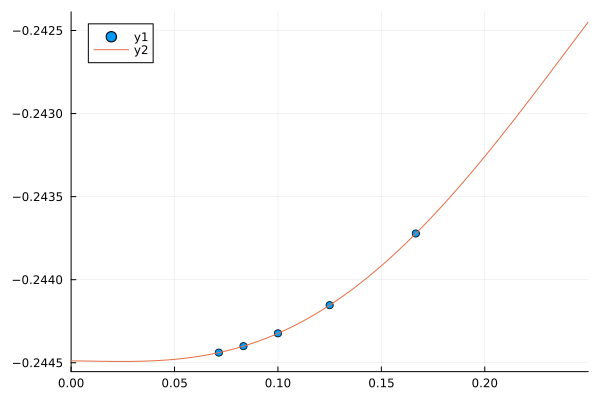

In [10]:
# load the data, below is for λ = 0.5, n = -2cos(4λ)
Λs = load("ev_no_defect.jld2", "data")
Λ0(L) = abs(Λs[L][1]);
println(Λ0(14))
@variables c1, c2, c3

f0(L) = -log(real(Λ0(L)))/L

# get and effective central charge from sizes L, L+1 and L+2
eq(L) = c1 - π*c2/6/L^2 + c3/L^4 - f0(L)
c_eff(L) = Symbolics.solve_for([eq(L), eq(L+2), eq(L+4)], [c1, c2, c3])[2]

Lrange = 6:2:14
c_effs = [c_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p0 = fit(Ls, c_effs)
println(p0(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, c_effs)
plot!(xfine, p0.(xfine), xlims=(0, 0.25))

The central charge extracted from the transfer matrix matches the expected value to a good accuracy:

In [14]:
c = CentralCharge(:β, β)

c = -0.24449659497486564 + 0.0im, β = -0.7978845608028654 - 0.0im


## Two-point function of the two-leg operator
### From the spectrum

We extract the dimension of the two-leg operator thanks to

$$
-\frac{1}{L} \log(\frac{\Lambda(L)}{\Lambda_0(L)}) = \frac{2\pi\Delta}{L^2} + o(L^{-2}).
$$

where $\Lambda$ is the highest eigenvalue in the sector with two defects.

3.8173977612116134
0.21460557494452806


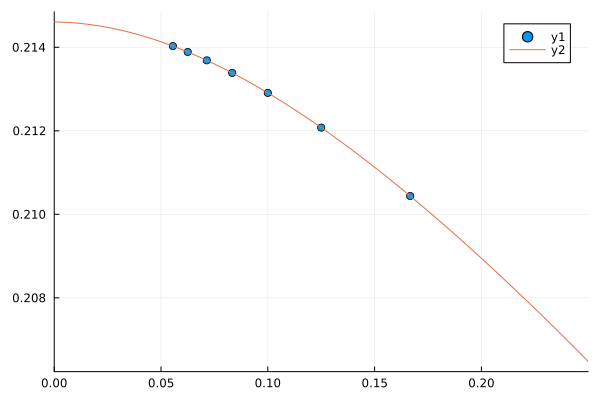

In [15]:
# load the data, below is for λ = 0.5, n = -2cos(4λ)
Λ1s = load("ev_2_defects.jld2", "data")
Λ1(L) = Λ1s[L][1];
println(log(abs(Λ1(6))))
@variables Δ

f1(L) = -log(real(Λ1(L)))/L

# get an effective scaling dimension at size L
eq(L) = f1(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:2:18
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

The expected result is $2\Delta_{(1, 0)} = 0.214601...$. The results match nicely. (notice that the convergence is from below whereas it was from above in the case of $O(n)$)

In [16]:
c = CentralCharge(:β, β)
V = Field(c, Kac=true, r=1, s=0)
println(V.Δ[:left] + V.Δ[:right])

0.2146018366025519 + 0.0im


### From the two-point function

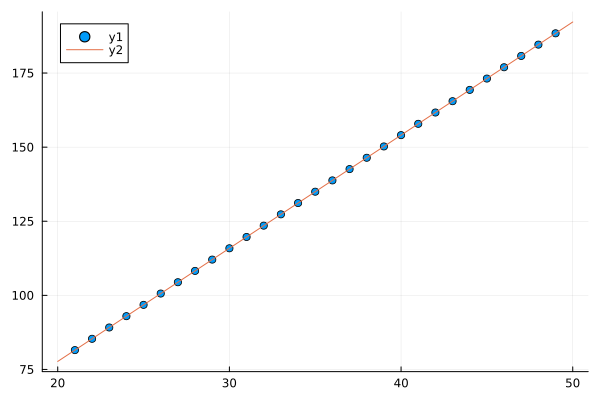

4.689582056016661e-13 + 0.0im
4.75181227699295e-10 + 0.0im
1.3663050024703693e-8 + 0.0im
1.088905318136213e-7 + 0.0im
4.618657297728035e-7 + 0.0im
1.3524348387861096e-6 + 0.0im
0.2348418014014269


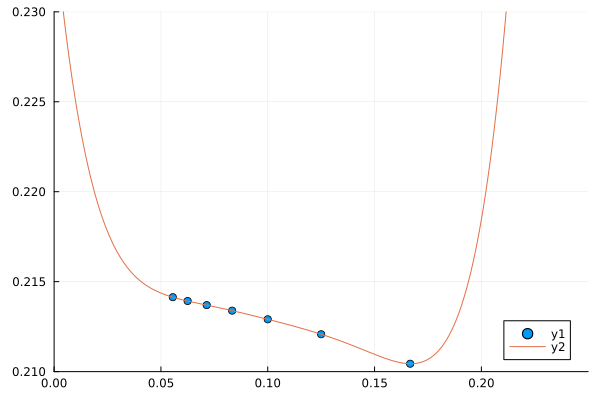

In [33]:
C10s = load("two_point_2defects.jld2", "data")
Ms(L) = sort([k for k in keys(C10s[L])])
C10Ls(L) = [C10s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC10 = Float64.(log.(C10Ls(L))))
model(L) = lm(@formula(logC10 ~ M), data(L))

L=6
mesh = 20:0.1:50
plt = scatter(Ms(L), log.(C10Ls(L)))
linearfit(L) = coef(model(L))
plot!(plt, mesh, linearfit(L)[1] .+ linearfit(L)[2].*mesh)
display(plt)

logΛ10(L) = fit(L)[2];
for L in 6:2:16
    println(1-logΛ10(L)/log(Λ1(L)))
end

# using the linear fit we almost perfectly match the eigenvalues of the transfer matrix,
# down to ~1e-7 at worst, using reasonably small cylinders: length 20-50.
@variables Δ

f10(L) = -logΛ10(L)/L

# get an effective scaling dimension at size L
eq(L) = f10(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:2:18
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25), ylims=(0.21, 0.23))

## Two-point function of the current

I now compute the two-point function $\langle \sigma | T^M | \sigma \rangle$, where $\sigma$ is a normalised state that is odd under the translation by half of the lattice sites.
The goal is to verify whether this two-point function is dominated by the contribution of a state whose dimension converges to the dimension of the current operator $V_{(1, 1)}$.

I expect that
$$
\underbrace{\langle \sigma | T(L)^M | \sigma \rangle}_{=: C(L, M)} = \Lambda^M
$$

where $\Lambda$ corresponds to the dimension of the current.

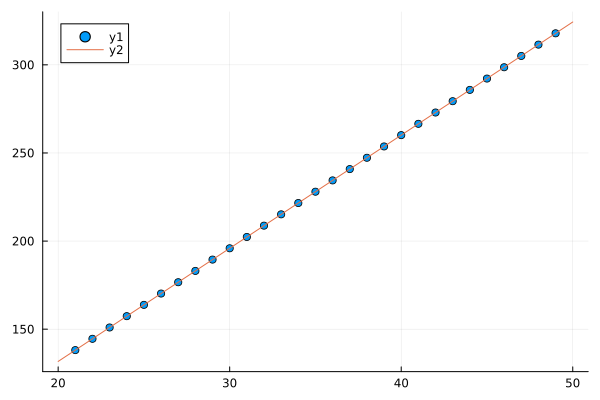

In [38]:
C11s = load("two_point_current.jld2", "Cs")
Ms(L) = sort([k for k in keys(C11s[L])])
C11Ls(L) = [C11s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC11 = Float64.(log.(C11Ls(L))))
model(L) = lm(@formula(logC11 ~ M), data(L))

L=6
mesh = 20:0.1:50
plt = scatter(Ms(L), log.(C11Ls(L)))
fit(L) = coef(model(L))
plot!(plt, mesh, fit(L)[1] .+ fit(L)[2].*mesh)
display(plt)

logΛ11(L) = fit(L)[2];

1.2141564568389296


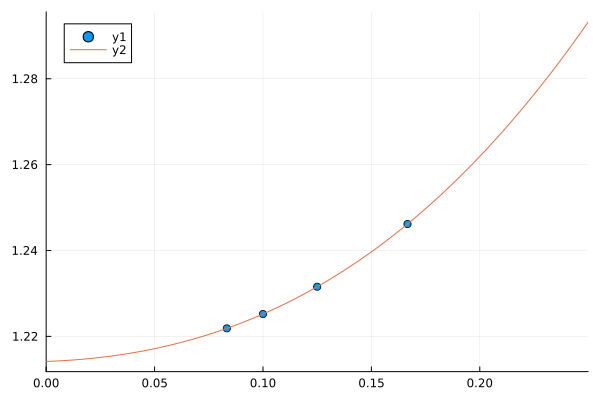

In [37]:
@variables Δ

f11(L) = -logΛ11(L)/L

# get an effective scaling dimension at size L
eq(L) = f11(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:2:12
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

There is a very good converge towards the operator $L_{-1} V_{(1, 0)}$. This operator has spin 1, so it is expected to find it in the sector that is odd under the half-lattice translation, however I don't understand why this sector isn't dominated by the current operator.

In [13]:
J = Field(c, Kac=true, r=1, s=1)
J.Δ[:left] + J.Δ[:right]

1.0000000000000002 + 0.0im